# 06c · GSE65391 · RNA_array · module scores in SLE against healthy children

Reads `projected_scores.rds` (notebook 05b).

**Samples.** The first visit of each child: 157 children with SLE and 46 healthy children (one sample
per child), all scored on the first-visit modules (notebook 05b).

**Test 1.** For each module: Wilcoxon rank-sum test of SLE against healthy scores; BH q across the 16
modules. Effect size: the difference in medians, in score units. **A finding** is q < 0.05.

**Comparison with Banchereau et al. 2016 (claim B5).** Against healthy controls, the paper reports
modules for erythropoiesis over-expressed and NK cell / cytotoxicity under-expressed in SLE (Fig. 1C).
Here: brown (red cell hub genes) and midnightblue (NK / cytotoxic hub genes).

**Test 2 (claim B1).** The paper reports an interferon signature in 84.8% of SLE samples (Fig. 1E),
using its own module definitions and a rule per sample (transcripts with fold change ≥ 1.5 and raw
difference ≥ 100 against the healthy median). Those module definitions are not part of this analysis,
so the paper's rule cannot be applied as written. **This test is ours, not the paper's:** the share of
SLE first visits whose interferon module (pink) score lies above the 97.5th percentile of the healthy
children, the upper limit of the central 95% reference interval of the healthy scores. The comparison
with 84.8% is therefore approximate and is reported as such.

In [1]:
source("../src/paths.R")
p <- readRDS(art("GSE65391", "projected_scores.rds"))
m <- p$meta; S <- p$scores
h <- m[m$disease == "Healthy", ]; h <- h[order(h$subject, h$visit), ]
healthy <- rownames(h)[!duplicated(h$subject)]
sle <- rownames(m)[m$disease == "SLE" & m$first_visit]
c(SLE_first_visits = length(sle), healthy_children = length(healthy))

SLE_first_visits healthy_children 
             157               46

In [2]:
res <- do.call(rbind, lapply(colnames(S), function(mo) {
  wt <- wilcox.test(S[sle, mo], S[healthy, mo])
  data.frame(module = mo, median_SLE = median(S[sle, mo]), median_healthy = median(S[healthy, mo]),
             difference = median(S[sle, mo]) - median(S[healthy, mo]), p = wt$p.value)
}))
res$q <- p.adjust(res$p, "BH")
res <- res[order(res$p), ]
format(res, digits = 3)

,module,median_SLE,median_healthy,difference,p,q
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
2,pink,0.01552,-0.1469,0.16243,4.55e-17,7.28e-16
11,black,0.00857,0.1089,-0.10033,1.35e-16,8.91e-16
15,salmon,0.01127,0.0342,-0.02289,1.67e-16,8.91e-16
14,lightcyan,-0.02064,-0.0798,0.05919,4.53e-10,1.81e-09
6,yellow,-0.00209,0.0740,-0.07612,6.95e-09,2.22e-08
16,cyan,0.00131,0.0717,-0.07035,6.84e-08,1.82e-07
1,turquoise,0.00850,0.0657,-0.05723,1.06e-07,2.13e-07
13,midnightblue,0.00196,0.0807,-0.07869,1.06e-07,2.13e-07
3,blue,0.00830,-0.0524,0.06074,2.88e-06,5.12e-06


**Result.** 13 of 16 modules differ between SLE and healthy children at q < 0.05. The largest
differences: pink (interferon, higher in SLE, q = 7 × 10⁻¹⁶), black and salmon (lower in SLE),
lightcyan (neutrophil granule, higher).

**Comparison with claim B5.**

In [3]:
res[res$module %in% c("brown", "midnightblue"), ]

,module,median_SLE,median_healthy,difference,p,q
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
13,midnightblue,0.001961239,0.08065534,-0.07869410,1.063723e-07,2.127446e-07
5,brown,-0.005460379,-0.03858215,0.03312177,1.929857e-03,2.807065e-03


**Result: claim B5 reproduced.** The red-cell module (brown) is higher in SLE (q = 0.003) and the
NK / cytotoxic module (midnightblue) is lower (q = 2 × 10⁻⁷), as in the paper's Fig. 1C.

**Test 2.** Share of SLE first visits above the healthy 97.5th percentile of the interferon (pink) score.

In [4]:
limit <- quantile(S[healthy, "pink"], 0.975)
c(healthy_97.5th_percentile = round(unname(limit), 4),
  SLE_above = sum(S[sle, "pink"] > limit), SLE_first_visits = length(sle),
  percent_above = round(100 * mean(S[sle, "pink"] > limit), 1))

healthy_97.5th_percentile                 SLE_above          SLE_first_visits 
                  -0.0181                  103.0000                  157.0000 
            percent_above 
                  65.6000

**Result: claim B1, approximate.** 65.6% of SLE first visits (103 of 157) lie above the healthy
97.5th percentile of the interferon module. The paper reports 84.8% with its own rule and module
definitions; the two numbers are not directly comparable, and both show an interferon signature in
most children with SLE.

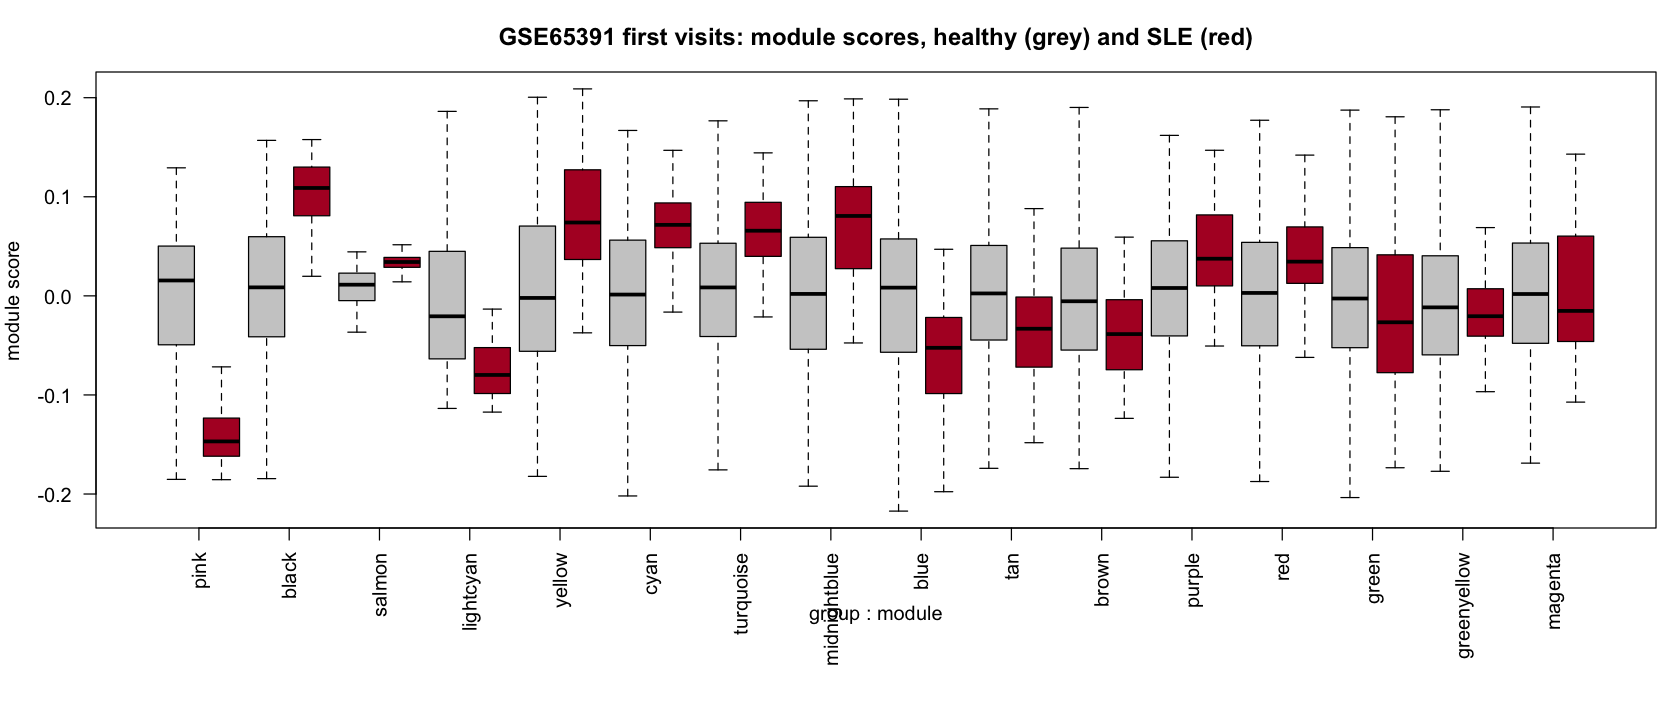

In [5]:
options(repr.plot.width = 14, repr.plot.height = 6)
figure <- function() {
  ord <- res$module
  long <- data.frame(module = factor(rep(ord, each = length(c(healthy, sle))), levels = ord),
                     group = rep(c(rep("healthy", length(healthy)), rep("SLE", length(sle))), length(ord)),
                     score = as.vector(sapply(ord, function(mo) c(S[healthy, mo], S[sle, mo]))))
  par(mar = c(8, 4, 3, 1))
  boxplot(score ~ group + module, data = long, las = 2, col = c("grey80", "#B2182B"), outline = FALSE,
          names = rep("", 2 * length(ord)), ylab = "module score", xaxt = "n",
          main = "GSE65391 first visits: module scores, healthy (grey) and SLE (red)")
  axis(1, at = seq(1.5, 2 * length(ord), by = 2), labels = ord, las = 2)
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "06c_GSE65391_RNA_array_sle_vs_healthy_1.png"), width = 14, height = 6, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}